In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adeenawaqar/heart-disease/Heart_Disease_Prediction.csv


# Name: Adeena

# Intership work on heart dissease task 
 

# Step1 : Import Libraries

In [32]:
# Disease Prediction from Medical Data (Heart Disease)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

# Step2: Load Dataset + Veiwing dataset 

In [33]:
df = pd.read_csv("/kaggle/input/datasets/adeenawaqar/heart-disease/Heart_Disease_Prediction.csv")

print("="*60)
print("First 5 Rows")
print(df.head())



First 5 Rows
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2               

In [34]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print("Columns")
print(df.columns)

Dataset Shape
(270, 14)
Columns
Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')


In [35]:
print("="*60)
print("Information")
print(df.info())



Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1),

In [36]:
print("="*60)
print("Statistical Summary")
print(df.describe())


Statistical Summary
              Age         Sex  Chest pain type          BP  Cholesterol  \
count  270.000000  270.000000       270.000000  270.000000   270.000000   
mean    54.433333    0.677778         3.174074  131.344444   249.659259   
std      9.109067    0.468195         0.950090   17.861608    51.686237   
min     29.000000    0.000000         1.000000   94.000000   126.000000   
25%     48.000000    0.000000         3.000000  120.000000   213.000000   
50%     55.000000    1.000000         3.000000  130.000000   245.000000   
75%     61.000000    1.000000         4.000000  140.000000   280.000000   
max     77.000000    1.000000         4.000000  200.000000   564.000000   

       FBS over 120  EKG results      Max HR  Exercise angina  ST depression  \
count    270.000000   270.000000  270.000000       270.000000      270.00000   
mean       0.148148     1.022222  149.677778         0.329630        1.05000   
std        0.355906     0.997891   23.165717         0.470952   

# Step3: Missing Values

In [37]:
print("="*60)
print("Missing Values")

print(df.isnull().sum())


Missing Values
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


#  Step4: Duplicate Values

In [38]:
print("="*60)
print("Duplicate Rows")

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows
0


# Step 5: EDA

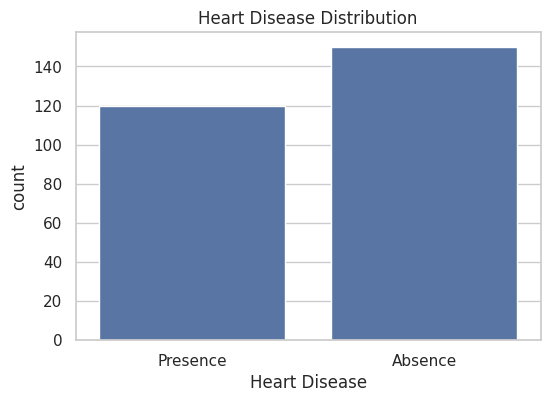

In [39]:
sns.set(style="whitegrid")

# Target Count

plt.figure(figsize=(6,4))
sns.countplot(x="Heart Disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()


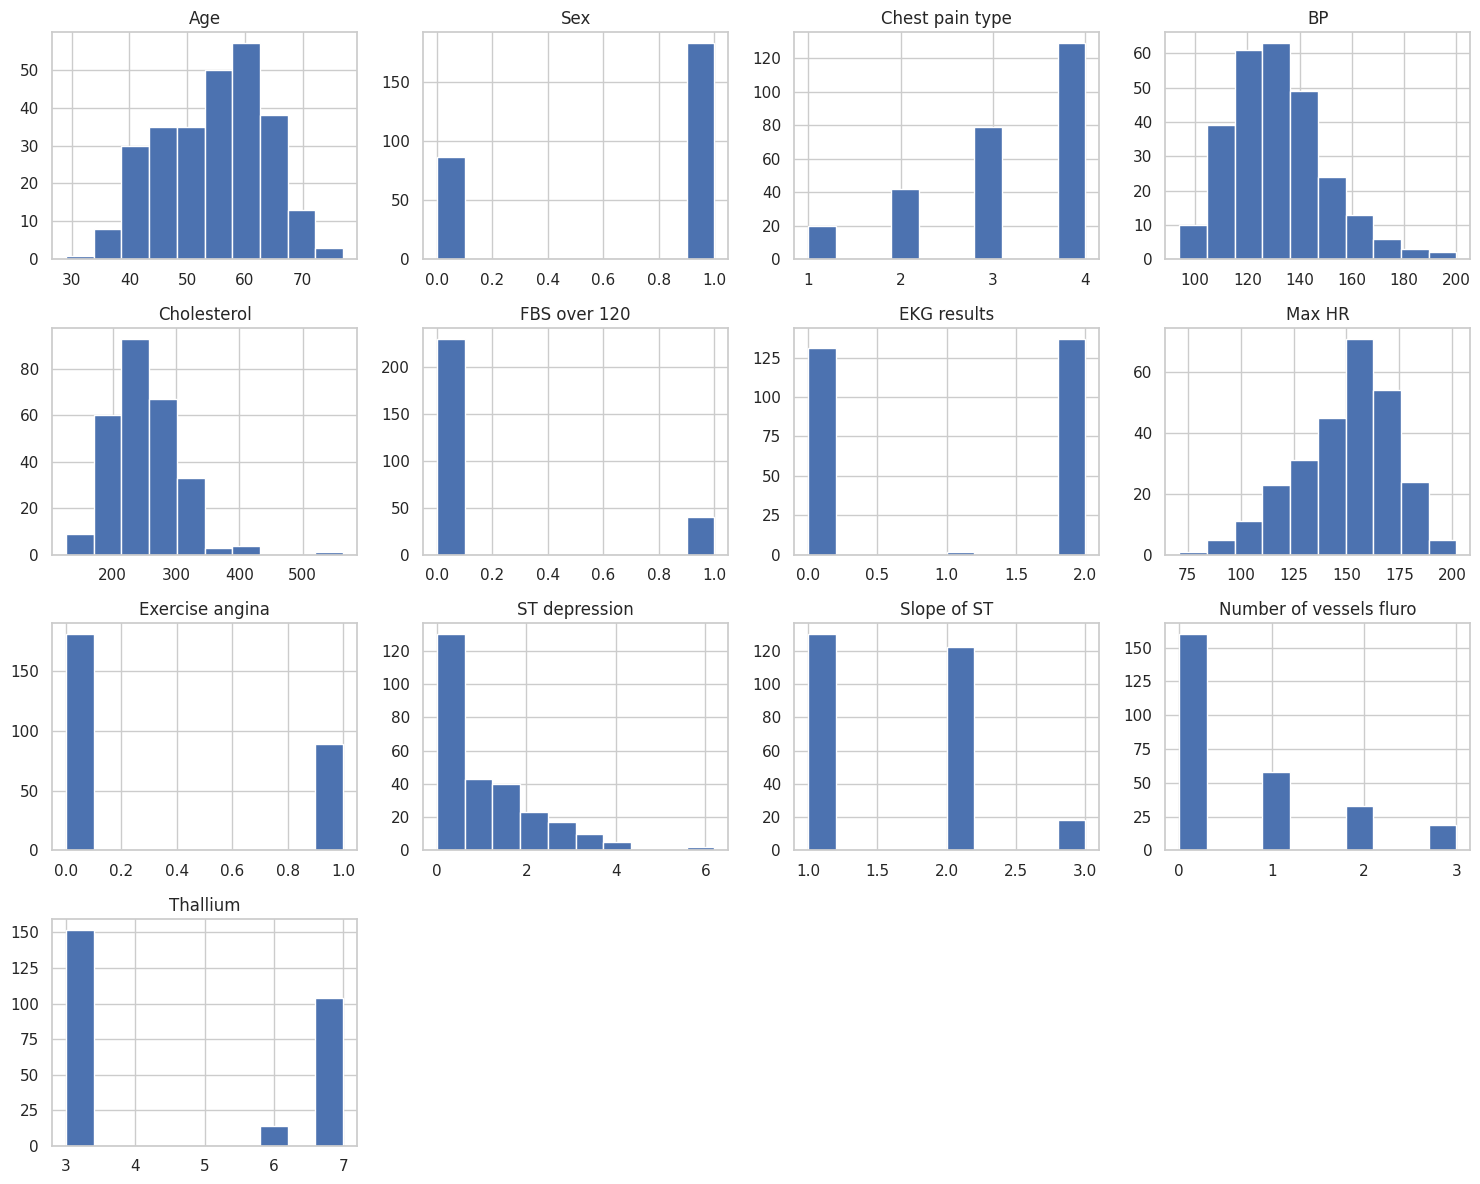

In [40]:
# Histograms

df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

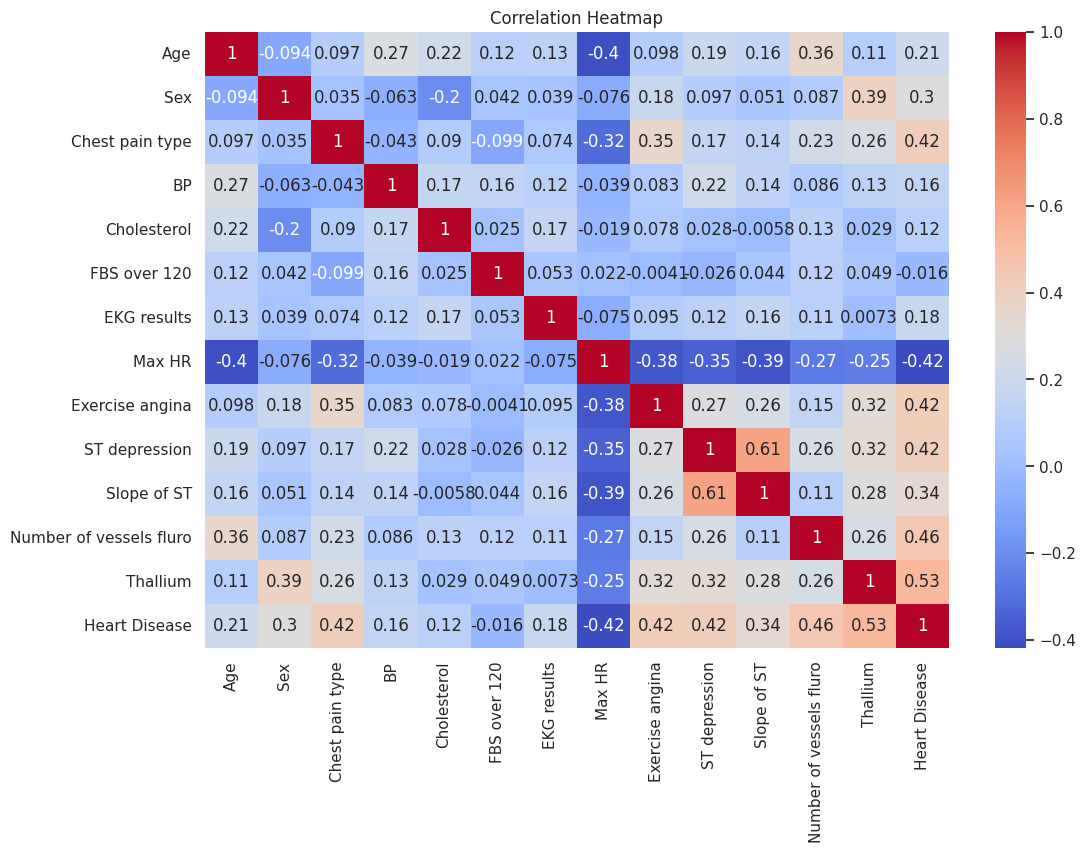

In [41]:
# Correlation Heatmap

temp = df.copy()

le = LabelEncoder()

for col in temp.columns:
    if temp[col].dtype=="object":
        temp[col]=le.fit_transform(temp[col])

plt.figure(figsize=(12,8))
sns.heatmap(temp.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

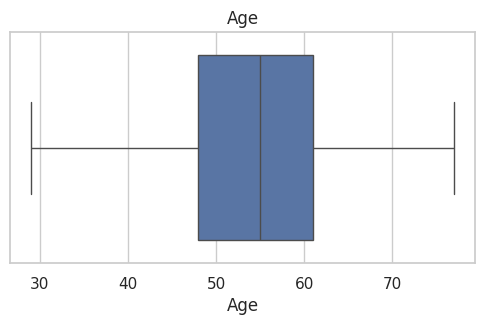

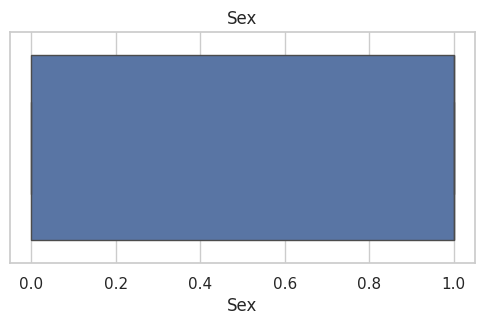

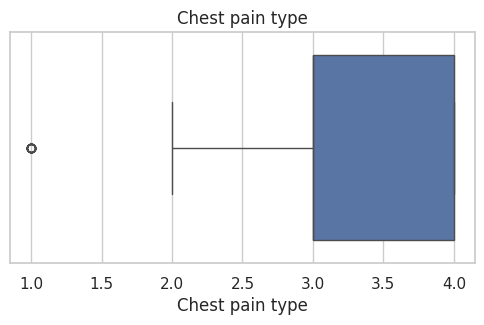

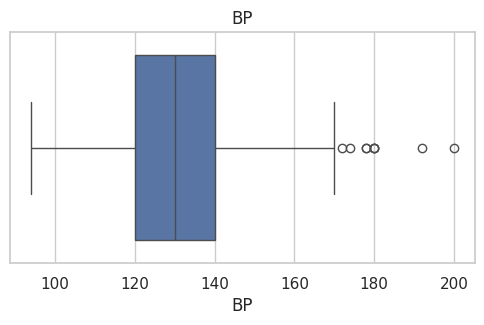

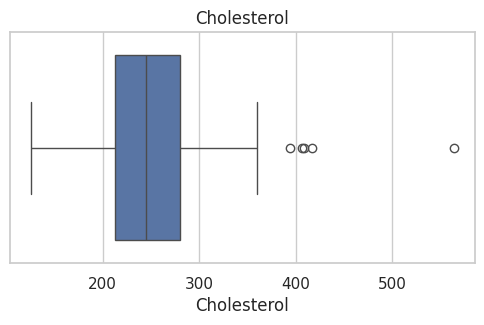

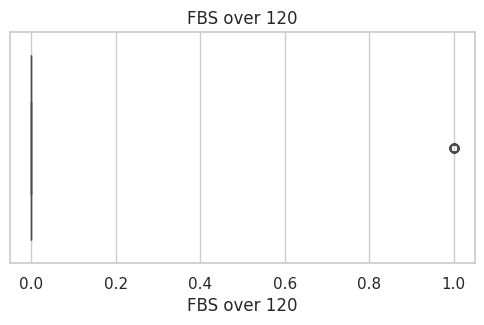

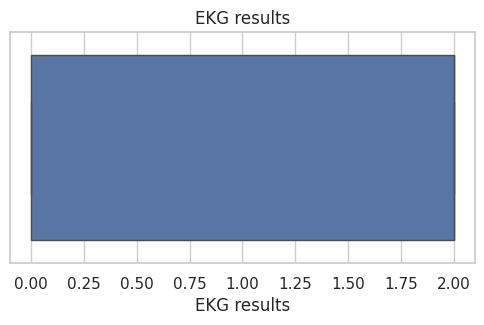

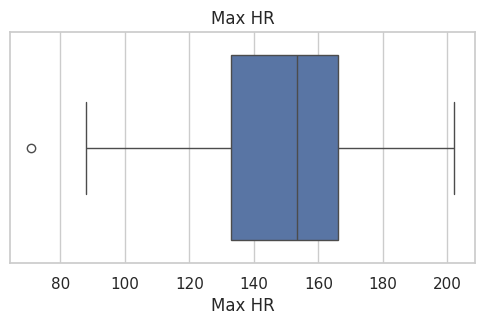

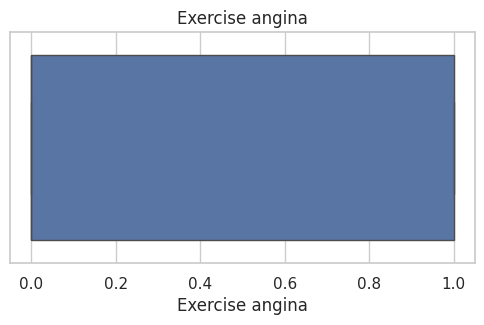

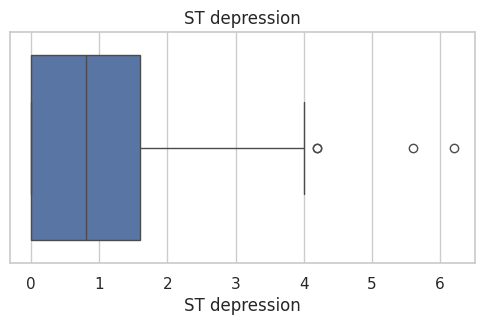

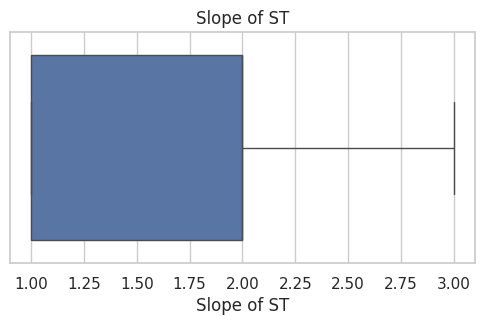

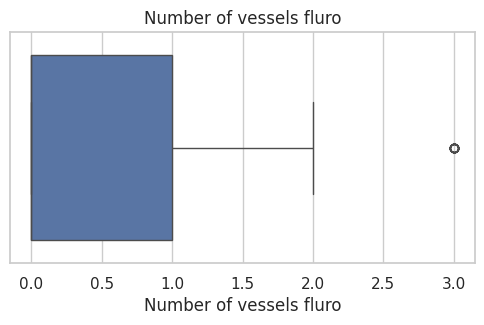

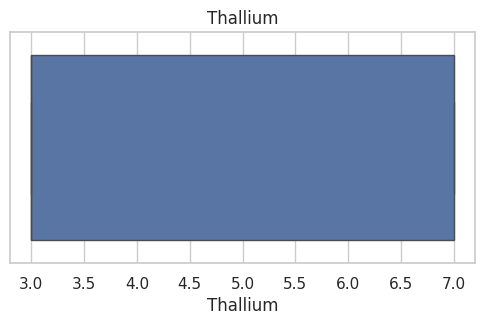

In [42]:
# Boxplots

numeric=df.select_dtypes(include=np.number).columns

for col in numeric:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Step6: Encoding

In [43]:
encoder=LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

print("="*60)
print(df.head())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium  Heart Disease  
0                        3         3              1  
1                        0         7              0  
2                        0


# Step7: Features & Target

In [48]:
X=df.drop("Heart Disease",axis=1)

y=df["Heart Disease"]

# Step8: Train Test Split

In [49]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*60)
print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)

Training Shape: (216, 13)
Testing Shape: (54, 13)


# Step9: StandardScaler


In [50]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

# Save scaler

joblib.dump(scaler,"scaler.pkl")

print("Scaler Saved!")


Scaler Saved!


# Step10: Model Apply



LOGISTIC REGRESSION
Accuracy : 0.8518518518518519

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



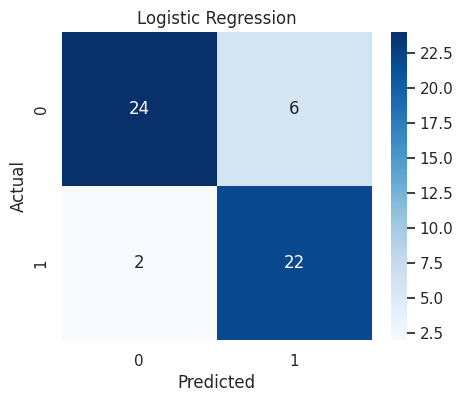

In [51]:
#  Logistic Regression

print("\n")
print("="*60)
print("LOGISTIC REGRESSION")

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled,y_train)

pred_lr=lr.predict(X_test_scaled)

acc_lr=accuracy_score(y_test,pred_lr)

print("Accuracy :",acc_lr)

print("\nClassification Report\n")

print(classification_report(y_test,pred_lr))

# confusion matrix 
cm=confusion_matrix(y_test,pred_lr)

# graph
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




SVM
Accuracy : 0.8148148148148148

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



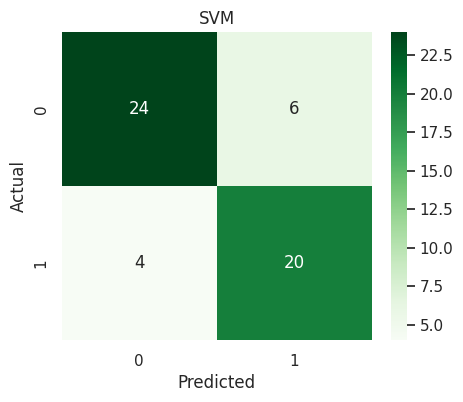

In [52]:
#  SVM

print("\n")
print("="*60)
print("SVM")

svm=SVC(kernel="rbf")

svm.fit(X_train_scaled,y_train)

pred_svm=svm.predict(X_test_scaled)

acc_svm=accuracy_score(y_test,pred_svm)

print("Accuracy :",acc_svm)

print("\nClassification Report\n")

print(classification_report(y_test,pred_svm))

# confusion matrix 
cm=confusion_matrix(y_test,pred_svm)

# graph
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")
plt.title("SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Random Forest
Accuracy : 0.8333333333333334

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



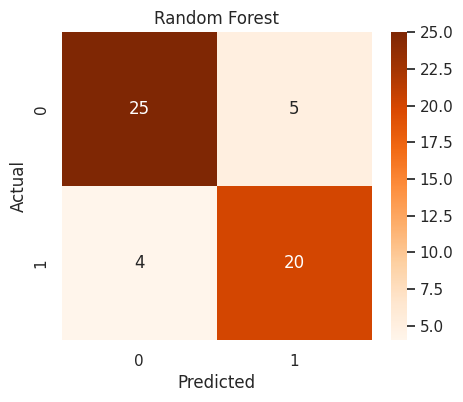

In [53]:
# ============================================================
# 12. Random Forest
# ============================================================

print("\n")
print("="*60)
print("Random Forest")

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

acc_rf=accuracy_score(y_test,pred_rf)

print("Accuracy :",acc_rf)

print("\nClassification Report\n")

print(classification_report(y_test,pred_rf))


# cinfusion matrix
cm=confusion_matrix(y_test,pred_rf)

# graph
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Oranges")
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



XGBoost
Accuracy : 0.8148148148148148

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



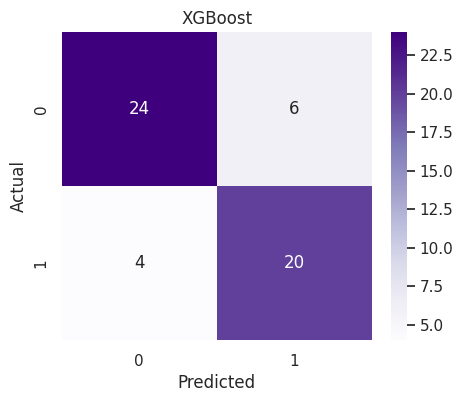

In [54]:
#  XGBoost

print("\n")
print("="*60)
print("XGBoost")

xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

acc_xgb=accuracy_score(y_test,pred_xgb)

print("Accuracy :",acc_xgb)

print("\nClassification Report\n")

print(classification_report(y_test,pred_xgb))


# confusion matrix
cm=confusion_matrix(y_test,pred_xgb)

# graph
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Purples")
plt.title("XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Step11: Accuracies Comparision



                 Model  Accuracy
0  Logistic Regression  0.851852
1                  SVM  0.814815
2        Random Forest  0.833333
3              XGBoost  0.814815


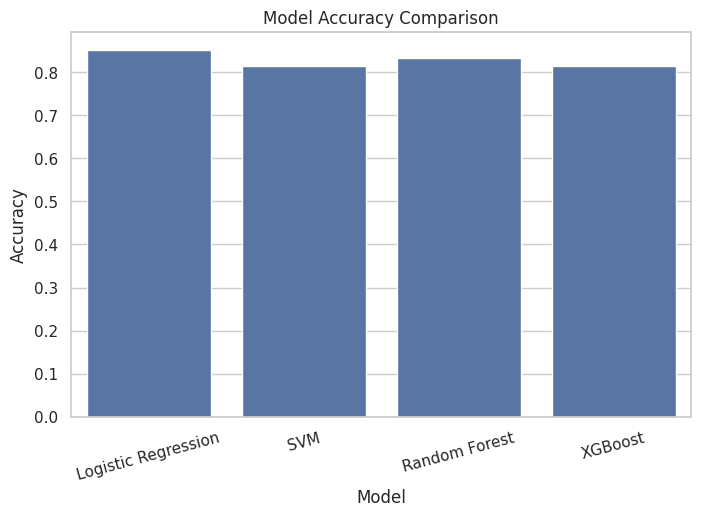

In [55]:

results=pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        acc_lr,
        acc_svm,
        acc_rf,
        acc_xgb
    ]

})

print("\n")
print("="*60)
print(results)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# Step12: Best Model

In [56]:
accuracies={
    "Logistic Regression":acc_lr,
    "SVM":acc_svm,
    "Random Forest":acc_rf,
    "XGBoost":acc_xgb
}

best=max(accuracies,key=accuracies.get)

print("="*60)
print("Best Model :",best)
print("Accuracy :",accuracies[best])

Best Model : Logistic Regression
Accuracy : 0.8518518518518519


# Step13: Save Best Model

In [58]:
if best=="Logistic Regression":
    joblib.dump(lr,"heart_disease_model.pkl")

elif best=="SVM":
    joblib.dump(svm,"heart_disease_model.pkl")

elif best=="Random Forest":
    joblib.dump(rf,"heart_disease_model.pkl")

else:
    joblib.dump(xgb,"heart_disease_model.pkl")

print("="*60)
print("Best Model Saved Successfully!")
print("File Name : heart_disease_model.pkl")
print("Scaler Saved : scaler.pkl")
print("="*60)

Best Model Saved Successfully!
File Name : heart_disease_model.pkl
Scaler Saved : scaler.pkl
